<h2> Python - maski + krótkie wprowadzenie </h2>

<h3> 14.04.2026 </h3>

Wrzucam tutaj dokument w formacie notatnika (IPython Notebook). Ta forma pozwala na zawrcie kodu, wyników oraz tesktu. Wyniki które się wyświetlają są z kodu puszczonego przeze mnie - u was zadziała jak zmienicie ścieżki.

<h3> 1. Wczytanie ścieżek </h3>

In [60]:
#na początek zaimporotwanie modułów - podstawowy python jest raczej ubogi, więc często trzeba coś importować
import os #ten tutaj jest pomocny do poruszania się w plikach

#ścieżki do naszych folderów (bezwględne)
dir_expert1 = r"C:\Users\berta\Desktop\Liceum\crops_outputs\expert1" #typ: string
dir_expert2 = r"C:\Users\berta\Desktop\Liceum\crops_outputs\expert2"
dir_expert3 = r"C:\Users\berta\Desktop\Liceum\crops_outputs\expert3"


all_dirs = [dir_expert1, dir_expert2, dir_expert3] #typ: list
all_imgs = {} #typ: dictionary

#pętla z pętlami zagnieżdżonymi - by "przejść" przez wszystkie (pod)foldery i pliki z danym rozszerzeniem
for path in all_dirs:
    print(f"Przetwarzam: {path}")
    dir_imgs = {}
    
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith('.png'):
                dir_imgs[f] = os.path.join(root, f)
    all_imgs[path] = dir_imgs


#wyświetlamy wynik 
for s in all_dirs:
    print(f"Folder {s} zawiera {len(all_imgs[s])} zdjęć.")

print(type(dir_expert1)) #jak nie znamy typu możemy sobie wyprintować jaki to typ

Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\expert1
Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\expert2
Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\expert3
Folder C:\Users\berta\Desktop\Liceum\crops_outputs\expert1 zawiera 91 zdjęć.
Folder C:\Users\berta\Desktop\Liceum\crops_outputs\expert2 zawiera 90 zdjęć.
Folder C:\Users\berta\Desktop\Liceum\crops_outputs\expert3 zawiera 90 zdjęć.
<class 'str'>


<h3> 2. Sprawdzenie nazw - czy się zgadzają pomiędzy plikami </h3>

In [61]:
#tworzenie zbiorów nazw plików
names1 = set(all_imgs[dir_expert1].keys()) #typ: zbiór
names2 = set(all_imgs[dir_expert2].keys())
names3 = set(all_imgs[dir_expert3].keys())

#pula wspólnych nazw -> wykorzystujemy & (AND) -> iloczyn logiczny -> dany element MUSI znajdować się we WSZYSTKICH zbiorach
common_names = names1 & names2 & names3
#wszytskie możliwości -> wykorzystujemy | (OR) -> suma logiczna -> dany element MUSI znajdować się w PRZYNAJMNIEJ JEDNYM zbiorze
all_possibilities = names1 | names2 | names3

#wyświetlamy wynik 
print("-" * 30)
print(f"Razem unikalnych zdjęć we wszystkich folderach: {len(all_possibilities)}")
print(f"Zdjęć posiadanych przez komplet ekspertów: {len(common_names)}")
print("-" * 30)


#pętla wyświetlająca braki lub informacje o komplecie 
for i, expert_names in enumerate([names1, names2, names3], 1):
    missing_files = all_possibilities - expert_names
    if missing_files:
        print(f"Ekspert {i} nie ma plików ({len(missing_files)} szt.): {list(missing_files)[:5]}...")
    else:
        print(f"Ekspert {i} ma wszystkie zdjęcia.")


------------------------------
Razem unikalnych zdjęć we wszystkich folderach: 181
Zdjęć posiadanych przez komplet ekspertów: 0
------------------------------
Ekspert 1 nie ma plików (90 szt.): ['CONV_fot_25Gy10_nr2.0_00029_plsmix2.png', 'CONV_fot_25Gy10_nr2.0_00032_plsmix36.png', 'CONV_fot_0Gy1_nr5.0_00002_plsmix10.png', 'CONV_fot_25Gy10_nr2.0_00004_plsmix13.png', 'CONV_fot_25Gy10_nr2.0_00015_plsmix7.png']...
Ekspert 2 nie ma plików (91 szt.): ['CONV_fot_25Gy10_nr2.0_00031_plsmix9 1.png', 'CONV_fot_0Gy1_nr6.0_00002_plsmix31 1.png', 'CONV_fot_25Gy10_nr2.0_00015_plsmix58 1.png', 'CONV_fot_0Gy1_nr5.0_00040_plsmix2 1.png', 'CONV_fot_0Gy1_nr5.0_00008_plsmix2 1.png']...
Ekspert 3 nie ma plików (91 szt.): ['CONV_fot_25Gy10_nr2.0_00031_plsmix9 1.png', 'CONV_fot_0Gy1_nr6.0_00002_plsmix31 1.png', 'CONV_fot_25Gy10_nr2.0_00015_plsmix58 1.png', 'CONV_fot_0Gy1_nr5.0_00040_plsmix2 1.png', 'CONV_fot_0Gy1_nr5.0_00008_plsmix2 1.png']...


<h3> 2.1 Sprawdzenie nazw - nie zgadzają się. </h3>
Wyświetlony powyżej wynik pozwala zauważyć, że nazwy jednego z folderów mają dodatkową spację i cyfrę 1. Można usunąć " 1" by zunifikować nazwy

In [62]:
#pętla pozwalająca na zmianę nazw określonych plików (nie zmienia nazw plików na dysku, jedynie w zbiorze)
for path in all_dirs:
    print(f"Przetwarzam: {path}")
    dir_imgs = {}
    
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith('.png'):
                clean_name = f
                if path == dir_expert1:
                    clean_name = f.replace(" 1.png", ".png")  # zmiana nazwy - co zmieniamy na co             
                dir_imgs[clean_name] = os.path.join(root, f)
    
    all_imgs[path] = dir_imgs

names1 = set(all_imgs[dir_expert1].keys())
names2 = set(all_imgs[dir_expert2].keys())
names3 = set(all_imgs[dir_expert3].keys())

common_names = names1 & names2 & names3
print(f"\nPo oczyszczeniu nazw, wspólnych plików jest: {len(common_names)}")

Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\expert1
Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\expert2
Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\expert3

Po oczyszczeniu nazw, wspólnych plików jest: 89


<h3> 2.2 Sprawdzenie nazw - wciąż nie zgadzają się. </h3>
Na 90 plików jakie powinniśmy mieć, mamy 89 z wspólnymi nazwami. 1 brakuje...

In [63]:
all_possibilities = names1 | names2 | names3

analyzes = [
    ("Expert 1", names1),
    ("Expert 2", names2),
    ("Expert 3", names3)
]

for expert_names, names_set in analyzes:
    missing_files = all_possibilities - names_set
    
    if missing_files:
        print(f"\nU {expert_names} brakuje {len(missing_files)} plików:")
        for b in sorted(missing_files):
            print(f"  - {b}")
    else:
        print(f"\n{expert_names} posiada komplet zdjęć.")



U Expert 1 brakuje 1 plików:
  - CONV_fot_25Gy10_nr2.0_00021_plsmix9.png

U Expert 2 brakuje 2 plików:
  - CONV_fot_25Gy10_nr2.0_00019_plsmix7 2.png
  - CONV_fot_25Gy10_nr2.0_00021_plsmix9-1.png

U Expert 3 brakuje 2 plików:
  - CONV_fot_25Gy10_nr2.0_00019_plsmix7 2.png
  - CONV_fot_25Gy10_nr2.0_00021_plsmix9-1.png


<h3> 2.3 Sprawdzenie nazw - znamy te, które sie nie zgadzają </h3>

In [64]:
file_out = "CONV_fot_25Gy10_nr2.0_00019_plsmix7 2.png" #ręcznie wpisaliśmy nazwę zdublowanego pliku - do usunięcia
all_imgs[dir_expert1].pop(file_out, None)


old_name = "CONV_fot_25Gy10_nr2.0_00021_plsmix9-1.png" #ręcznie wpisaliśmy nazwę plików do zmiany - starą i nową
new_name = "CONV_fot_25Gy10_nr2.0_00021_plsmix9.png"

if old_name in all_imgs[dir_expert1]:
    path = all_imgs[dir_expert1].pop(old_name)    
    all_imgs[dir_expert1][new_name] = path


names1 = set(all_imgs[dir_expert1].keys())
names2 = set(all_imgs[dir_expert2].keys())
names3 = set(all_imgs[dir_expert3].keys())

common_names = names1 & names2 & names3
print(f"\nPo oczyszczeniu nazw, wspólnych plików jest: {len(common_names)}")


Po oczyszczeniu nazw, wspólnych plików jest: 90


<h3> 2.4 Unifikacja nazw - kopia folderów z uwzględnieniem nowych nazw </h3>

In [65]:
import shutil #biblioteka do operacji na plikach

#ścieżka do folderu do którego skopiowane będą pliki
copy_dir = r"C:\Users\berta\Desktop\Liceum\crops_outputs\correction"


#os.path -> do operacji związanych ze ścieżkami plików
for file_path in all_dirs:
    expert_name = os.path.basename(file_path) #ze ścieżki pobiera jedynie ostatni fragment -> np. dla C:\Users\berta\Desktop\Liceum\crops_outputs\expert1 output to expert1

    for clean_name, old_path in all_imgs[file_path].items():
        original_root = os.path.dirname(old_path) #czy są podfoldery
        rel_path = os.path.relpath(original_root, file_path) #odtwarzanie podfolderów
        
        target_dir = os.path.join(copy_dir, expert_name, rel_path) #nowa ścieżka
        
        if not os.path.exists(target_dir):
            os.makedirs(target_dir)
            
        new_file_path = os.path.join(target_dir, clean_name)        
        shutil.copy2(old_path, new_file_path) #kopiowanie danych

print(f"Ścieżka do pliku z poprawionymi nazwami: {copy_dir}")

Ścieżka do pliku z poprawionymi nazwami: C:\Users\berta\Desktop\Liceum\crops_outputs\correction


<h3> 2.5 Weryfikacja skopiowanych plików - czy teraz nazwy się zgadzają </h3>

In [66]:
dir_expert1 = os.path.join(copy_dir, "expert1") #konkatenacja (połączenie zmiennych typu string w 1) -> tu ścieżka do podfolderów ekspertów 
dir_expert2 = os.path.join(copy_dir, "expert2")
dir_expert3 = os.path.join(copy_dir, "expert3")


all_dirs = [dir_expert1, dir_expert2, dir_expert3] 
all_imgs = {} 

for path in all_dirs:
    print(f"Przetwarzam: {path}")
    dir_imgs = {}
    
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith('.png'):
                dir_imgs[f] = os.path.join(root, f)
    all_imgs[path] = dir_imgs


common_names = names1 & names2 & names3
all_possibilities = names1 | names2 | names3

print("-" * 30)
print(f"Razem unikalnych zdjęć we wszystkich folderach: {len(all_possibilities)}")
print(f"Zdjęć posiadanych przez komplet ekspertów: {len(common_names)}")
print("-" * 30)

Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\correction\expert1
Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\correction\expert2
Przetwarzam: C:\Users\berta\Desktop\Liceum\crops_outputs\correction\expert3
------------------------------
Razem unikalnych zdjęć we wszystkich folderach: 90
Zdjęć posiadanych przez komplet ekspertów: 90
------------------------------


<h3> 3. Operacje na obrazach </h3>

Skoro ujednoliciliśmy nazwy, możemy porównać nasze obrazy. 

**Surowy obraz** - obraz w skali szarości przedsatwiający plazmid w formie open circular

**Obraz z wyrysowanym plazmidem** - obraz z wyrysowanym na czerwono plazmidem

**Maska binarna** - obraz zawierający jedynie piksele o barwie czarnej i białej (bez innych odcieni szarości). Piksele przymują wartości 0 dla czarnego tła i 255 dla białego obiektu (tu plazmidu)


By otrzymać maskę z waszego obrazu musimy zastosować progowanie. Ustalamy jakiś próg (threshold), wartości poniżej progu staną się czarne (wartość piksela 0), a powyżej - białe (wartość piksela 255).


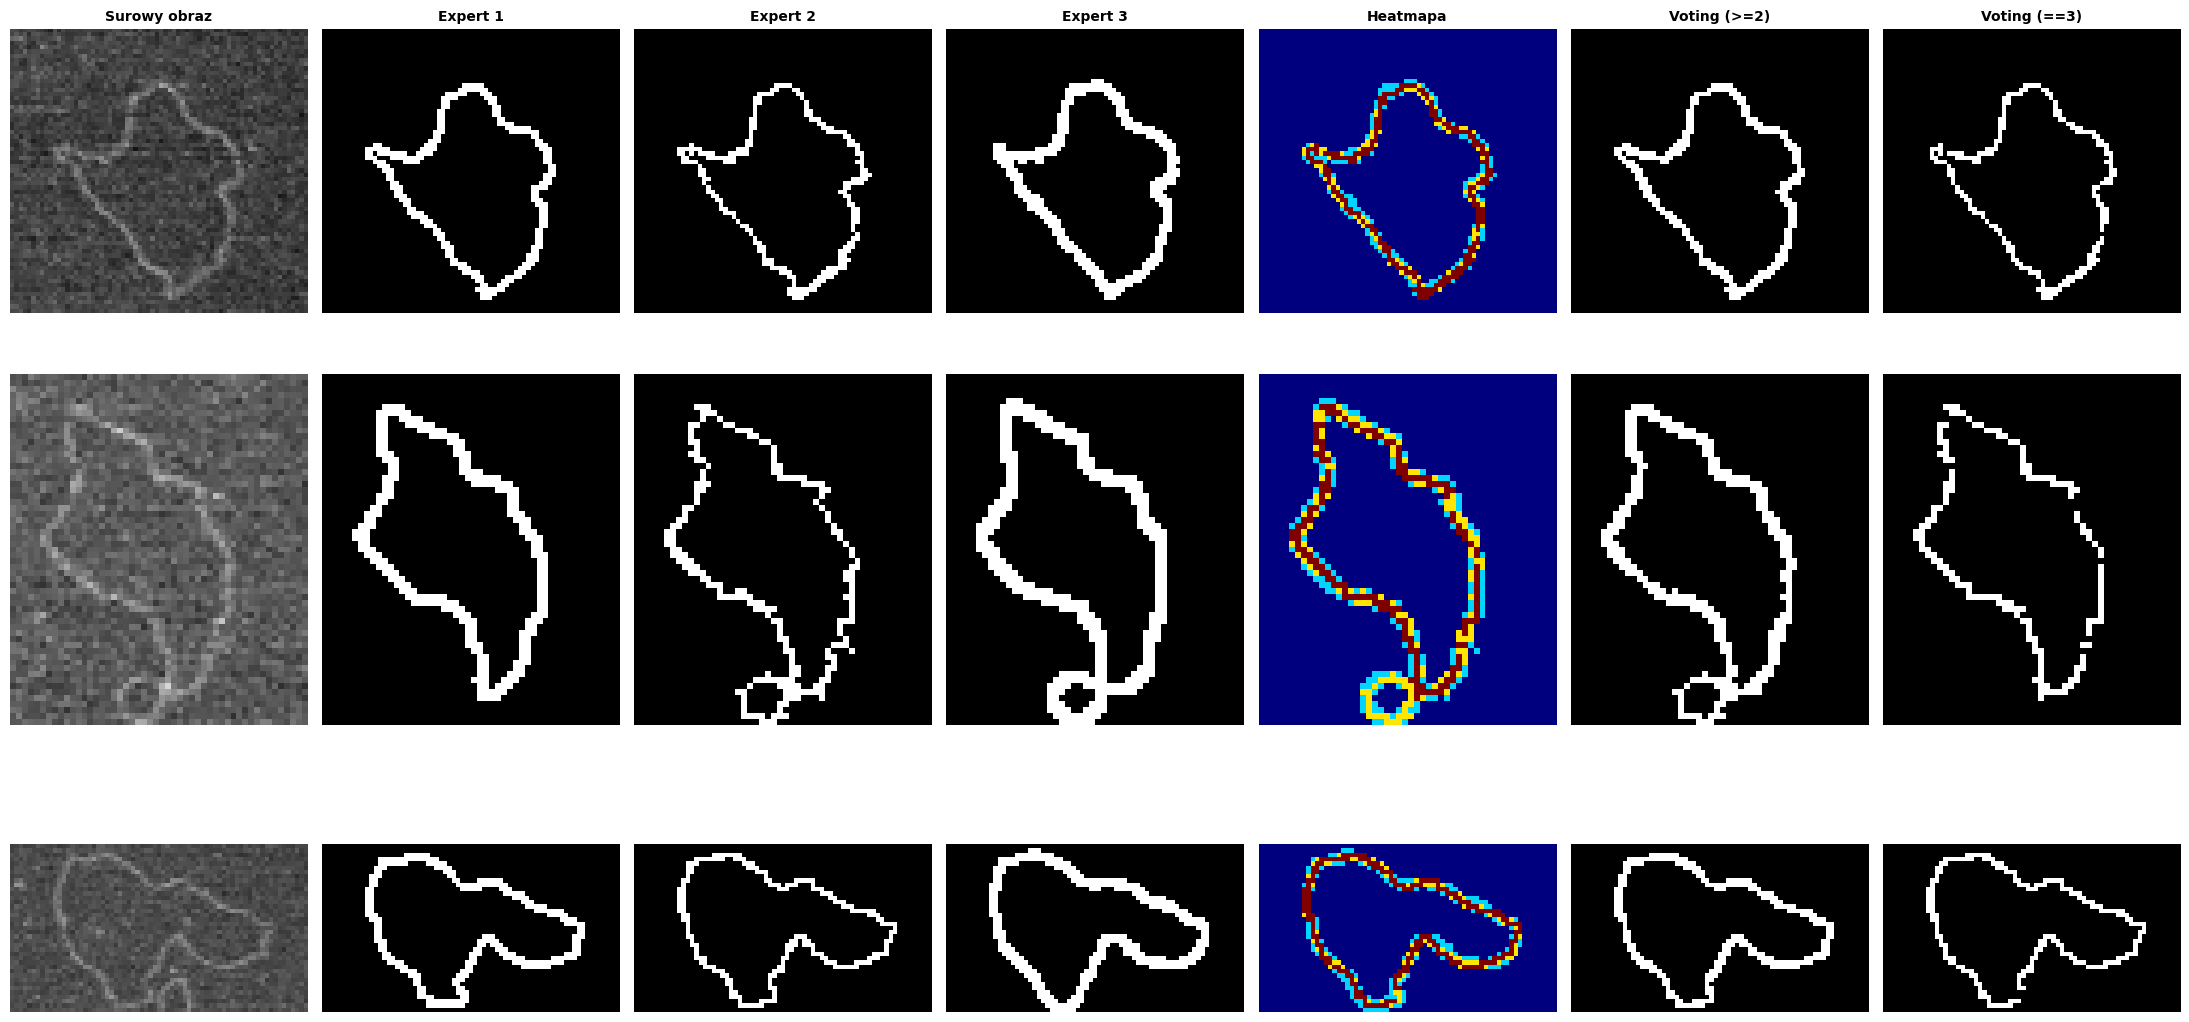

In [67]:
import numpy as np #biblioteka NumericalPython -> do oblcizeń (ma tablice, basic python nie ma), wcyztywana tu jako skrót "np"
import cv2 #biblioteka OpenCV -> do przetwarzania obrazów
import random #do losowania liczb
import matplotlib.pyplot as plt #do wizualizacji, wykresów, wczytywana jako plt

#losujemy 3 pliczki by nie wizualizować wszytkich, a za każdym razem coś innego zobaczyć
random_files = random.sample(list(common_names), 3) 


#tu jeszcze ściezka do folderu z surowym obrazem
dir_raw_imgs = r"C:\Users\berta\Desktop\Liceum\raw_imgs"

#mapowanie pliku surowego 
raw_map = {}
for root, dirs, files in os.walk(dir_raw_imgs):
    for f in files:
        if f.lower().endswith('.png'):
            raw_map[f] = os.path.join(root, f)

#FUNKCJA do otrzymywania maski binarnej z obrazu z plazmidem na czerowno
def get_binary_mask(img_path):
    img = cv2.imread(img_path)

    #open cv zapisuje kolory jako B G R, zakres każdego z kanałów wynosi od 0 do 255
    lower_red = np.array([0, 0, 150]) # takie założenie o zakresie dla koloru czerownego. Dla innych kolorów byłby inne
    upper_red = np.array([100, 100, 255])
    return cv2.inRange(img, lower_red, upper_red) #każdy piksel oceniany czy znajduje się w zakresie (staje się biały), czy nie (staje się czarny)


#wykres: 3 rzędy, 7 kolumn oraz rozmiar obrazów
fig, axes = plt.subplots(3, 7, figsize=(22, 12))


#pętla - będzie miała tyle iteracji ile jest losowych plików 
for idx, filename in enumerate(random_files):

    p1 = all_imgs[dir_expert1][filename]
    p2 = all_imgs[dir_expert2][filename]
    p3 = all_imgs[dir_expert3][filename]
    
    raw_path = raw_map.get(filename)
    raw_img_bgr = cv2.imread(raw_path)
    raw_img = cv2.cvtColor(raw_img_bgr, cv2.COLOR_BGR2RGB) #zmiana na RGB -> standardowo używa się tego formatu. Chcemy wyświetlić zdjęcie to musimy RGB
    
    m1 = get_binary_mask(p1) #wykorzystanie funkcji, stworzenie obrazu binarnego 
    m2 = get_binary_mask(p2)
    m3 = get_binary_mask(p3)
    
    
    m1_bin = (m1 > 0).astype(np.uint8) # tu zmieniamy wartości pikseli -> zmaist 0 i 255 będziemy mieć 0 i 1
    m2_bin = (m2 > 0).astype(np.uint8)
    m3_bin = (m3 > 0).astype(np.uint8)
    
    summed_masks = m1_bin + m2_bin + m3_bin # zsumowanie masek -> od 0 (żaden ekspert nie zaznaczył) do 3 (wszyscy eksperci zazznaczyli)

    #stworzenie nowych masek bazując na opinii wszystkich ekspertów. 
    voting_thr2 = (summed_masks >= 2).astype(np.uint8) * 255 #tutaj próg 2 -> co najmniej 2 ekspertów musiało zaznaczyć obszar
    voting_thr3 = (summed_masks >= 3).astype(np.uint8) * 255  #tutaj próg 3 -> wszyscy eksperci musieli zaznaczyć tak samo obszar
    #mnożymy *255 by wrócić do obrazu bianrnego [0, 255]
    

    #do wykresu:
    titles = ['Surowy obraz', 'Expert 1', 'Expert 2', 'Expert 3', 'Heatmapa', 'Voting (>=2)', 'Voting (==3)']
    images = [raw_img, m1, m2, m3, summed_masks, voting_thr2, voting_thr3]
    
    for col, (img, title) in enumerate(zip(images, titles)):
        ax = axes[idx, col]
        
        if title == 'Heatmapa':
            im = ax.imshow(img, cmap='jet') #nałożone na siebie 3 maski mozemy zwizualizować jako heatmapę
        elif len(img.shape) == 2:
            ax.imshow(img, cmap='gray') #maska bianrna jako skala szarości = czarny i biały
        else:
            ax.imshow(img) #raw image
            
        if idx == 0: ax.set_title(title, fontweight='bold', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()